# PHASE 1: DATA INSPECTION 
## 1. Dataset Verification

In [112]:
import pandas as pd

# Loads CSV file
df = pd.read_csv("E:\INCOIS Internhip\DataRequest_70E_78E_5N_12N.csv", low_memory=False)

# Views first few rows
print(df.head())

# Checks all columns
print("Columns:", df.columns.tolist())

                 DATES        LON    LAT   Depth(m)  TEMP(degC)  PSAL(psu)  \
0  30-11-2005 06:00:00  71.787003  5.793   4.174872   28.430000  36.099998   
1  30-11-2005 06:00:00  71.787003  5.793   9.343654   28.429001  36.099998   
2  30-11-2005 06:00:00  71.787003  5.793  15.903858   28.429001  36.098999   
3  30-11-2005 06:00:00  71.787003  5.793  29.421249   28.162001  36.250999   
4  30-11-2005 06:00:00  71.787003  5.793  38.863057   28.028999  36.240002   

     WMOID  CYCLE Temp_QC_Flag PSAL_QC_Flag  
0  1900185     77            1            1  
1  1900185     77            1            1  
2  1900185     77            1            1  
3  1900185     77            1            1  
4  1900185     77            1            1  
Columns: ['DATES', 'LON', 'LAT', 'Depth(m)', 'TEMP(degC)', 'PSAL(psu)', 'WMOID', 'CYCLE', 'Temp_QC_Flag', 'PSAL_QC_Flag']


## 2. Variables Datatypes, Statistics, Missing Values and Range

### Datatypes

In [113]:
# Data types of columns
print(df.dtypes)

DATES            object
LON             float64
LAT             float64
Depth(m)        float64
TEMP(degC)      float64
PSAL(psu)       float64
WMOID             int64
CYCLE             int64
Temp_QC_Flag     object
PSAL_QC_Flag     object
dtype: object


### Setting Data Types to correct forms (for Temp_QC_Flag, PSAL_QCFlag, DATES)

In [114]:
df["DATES"] = pd.to_datetime(df["DATES"], format="%d-%m-%Y %H:%M:%S")

df["Temp_QC_Flag"] = df["Temp_QC_Flag"].str.strip().replace("", None)
df["Temp_QC_Flag"] = pd.to_numeric(df["Temp_QC_Flag"], errors="coerce")

df["PSAL_QC_Flag"] = df["PSAL_QC_Flag"].str.strip().replace("", None)
df["PSAL_QC_Flag"] = pd.to_numeric(df["PSAL_QC_Flag"], errors="coerce")

In [115]:
#Check
print(df.dtypes)

DATES           datetime64[ns]
LON                    float64
LAT                    float64
Depth(m)               float64
TEMP(degC)             float64
PSAL(psu)              float64
WMOID                    int64
CYCLE                    int64
Temp_QC_Flag           float64
PSAL_QC_Flag           float64
dtype: object


### Statistics

In [117]:
# Basic statistics of numeric variables
print(df.describe())

                               DATES            LON            LAT  \
count                         612516  612516.000000  612516.000000   
mean   2018-02-17 11:42:44.101248768      72.714016       8.064395   
min              2005-01-01 01:44:00      70.004000       5.002000   
25%              2016-10-01 07:25:00      71.030000       6.521590   
50%              2017-11-20 18:30:00      72.380000       7.535000   
75%              2020-04-06 03:41:00      74.386000       9.523000   
max              2025-08-23 07:12:00      77.987000      12.000000   
std                              NaN       1.984403       1.961746   

            Depth(m)     TEMP(degC)      PSAL(psu)         WMOID  \
count  612516.000000  612351.000000  609619.000000  6.125160e+05   
mean      614.350529      12.068758      34.795701  3.573220e+06   
min         0.000000      -2.073000       0.000000  1.900185e+06   
25%       224.516678       7.904000      34.979000  2.902395e+06   
50%       524.206281      10.

### Missing Values Check

In [118]:
# Count missing values per column
print(df.isna().sum())

DATES              0
LON                0
LAT                0
Depth(m)           0
TEMP(degC)       165
PSAL(psu)       2897
WMOID              0
CYCLE              0
Temp_QC_Flag     158
PSAL_QC_Flag    2895
dtype: int64


### Range

QC_Flags Range

In [119]:
print(df["Temp_QC_Flag"].value_counts(dropna=False))
print(df["PSAL_QC_Flag"].value_counts(dropna=False))

Temp_QC_Flag
1.0    602107
4.0      9992
3.0       204
NaN       158
2.0        48
9.0         7
Name: count, dtype: int64
PSAL_QC_Flag
1.0    444539
4.0    155469
3.0      4991
2.0      4620
NaN      2895
9.0         2
Name: count, dtype: int64


Date/time range

In [121]:
print("Time range:", df["DATES"].min(), "to", df["DATES"].max())

Time range: 2005-01-01 01:44:00 to 2025-08-23 07:12:00


Location coverage

In [122]:
print("Latitude range:", df['LAT'].min(), "to", df['LAT'].max())
print("Longitude range:", df['LON'].min(), "to", df['LON'].max())

Latitude range: 5.002 to 12.0
Longitude range: 70.004 to 77.9869995117188


Depth spacing

In [123]:
# Depth stats per profile
depth_stats = df.groupby(["WMOID", "CYCLE"])["Depth(m)"].agg(["min", "max", "nunique"])
print(depth_stats.describe())

               min          max      nunique
count  3258.000000  3258.000000  3258.000000
mean      4.613454  1317.745159   186.885206
std      30.354609   753.591443   247.236931
min       0.000000     0.000000     1.000000
25%       0.993918   992.304217    49.250000
50%       3.975715  1683.223080    70.000000
75%       4.571760  1974.790157   316.750000
max     999.804312  1998.917926  1152.000000


## 3. Shape and Basic Structure
### Number of rows, Number of unique profiles and Depth points per profile distribution

Total rows: 612516
Number of floats (WMOID): 80
Number of unique profiles: 3258
count    3258.000000
mean      188.003683
std       247.188092
min         2.000000
25%        50.000000
50%        70.000000
75%       330.000000
max      1152.000000
dtype: float64


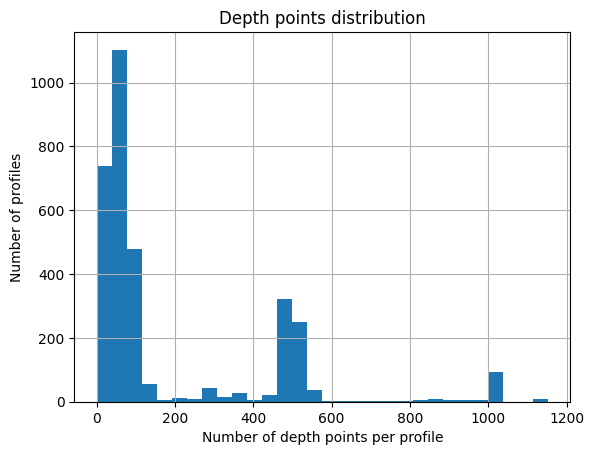

In [ ]:
import matplotlib.pyplot as plt

print("Total rows:", len(df))

# Counts how many unique floats and profiles
num_floats = df["WMOID"].nunique()
print("Number of floats (WMOID):", num_floats)


# Checks how many rows per profile (depth points)
profile_counts = df.groupby(["WMOID", "CYCLE"]).size()
num_profiles = df.groupby(['WMOID', 'CYCLE']).ngroups
print("Number of unique profiles:", num_profiles)
print(profile_counts.describe())

profile_lengths = df.groupby(['WMOID', 'CYCLE'])['Depth(m)'].nunique()
profile_lengths.describe()
profile_lengths.hist(bins=30)
plt.xlabel("Number of depth points per profile")
plt.ylabel("Number of profiles")
plt.title("Depth points distribution")
plt.show()

## 4. Example Visualizations

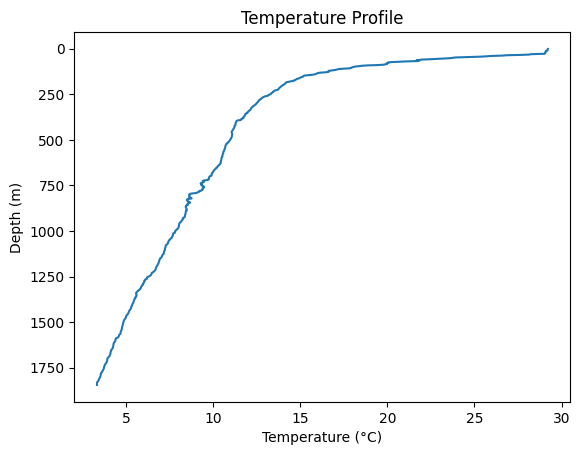

In [ ]:
# Random plotting code
import matplotlib.pyplot as plt
import random

rand_idx = random.randint(0, len(df)-1)
sample_profile = df[(df["WMOID"] == df["WMOID"].iloc[rand_idx]) &
                    (df["CYCLE"] == df["CYCLE"].iloc[rand_idx])]

plt.plot(sample_profile["TEMP(degC)"], sample_profile["Depth(m)"])
plt.gca().invert_yaxis()     # so depth increases downward
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Temperature Profile")
plt.show()

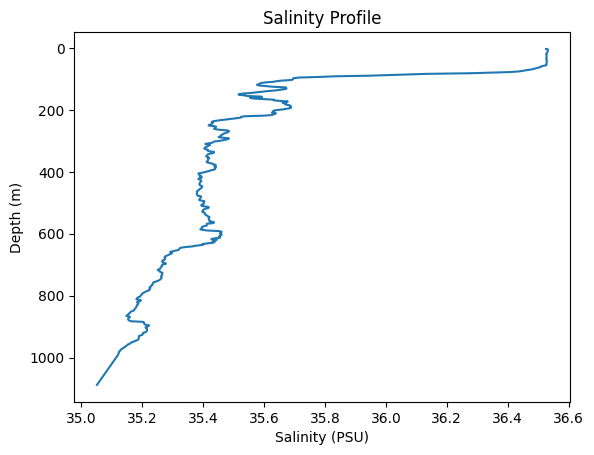

In [126]:
# Random plotting code
import matplotlib.pyplot as plt
import random

rand_idx = random.randint(0, len(df)-1)
sample_profile = df[(df["WMOID"] == df["WMOID"].iloc[rand_idx]) &
                    (df["CYCLE"] == df["CYCLE"].iloc[rand_idx])]

plt.plot(sample_profile["PSAL(psu)"], sample_profile["Depth(m)"])
plt.gca().invert_yaxis()     # so depth increases downward
plt.xlabel("Salinity (PSU)")
plt.ylabel("Depth (m)")
plt.title("Salinity Profile")
plt.show()

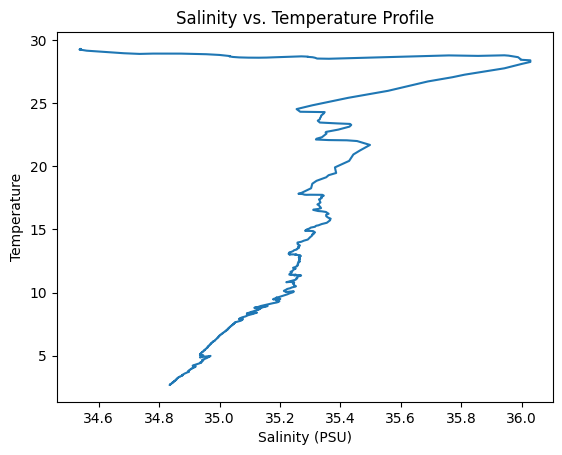

In [127]:
# Random plotting code
import matplotlib.pyplot as plt
import random

rand_idx = random.randint(0, len(df)-1)
sample_profile = df[(df["WMOID"] == df["WMOID"].iloc[rand_idx]) &
                    (df["CYCLE"] == df["CYCLE"].iloc[rand_idx])]

plt.plot(sample_profile["PSAL(psu)"], sample_profile["TEMP(degC)"])
plt.gca()    
plt.xlabel("Salinity (PSU)")
plt.ylabel("Temperature")
plt.title("Salinity vs. Temperature Profile")
plt.show()

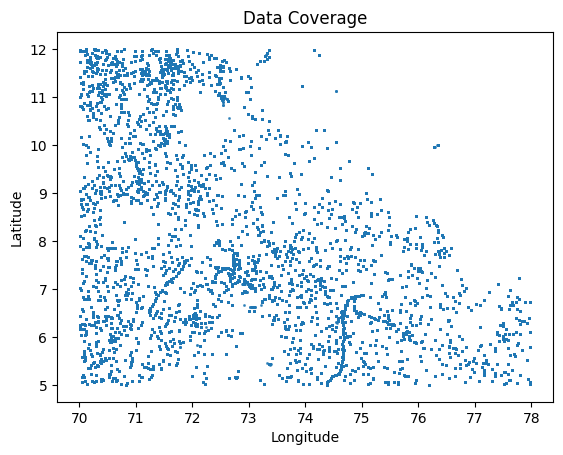

In [128]:
#Lat–Lon Scatter

plt.scatter(df['LON'], df['LAT'], s=1, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Data Coverage")
plt.show()

# PHASE 2: DATA CLEANING

## Step 1 — Keeping only good QC values

In [129]:
# Keeping only QC='1'
df_clean = df[(df['Temp_QC_Flag'] == 1) & (df['PSAL_QC_Flag'] == 1)]

print("Original rows:", len(df))
print("Rows after QC=1 filter:", len(df_clean))

# Profile count after filtering
num_profiles = df_clean.groupby(['WMOID', 'CYCLE']).ngroups
print("Number of profiles after QC filtering:", num_profiles)

Original rows: 612516
Rows after QC=1 filter: 444450
Number of profiles after QC filtering: 2208


## Step 2 — Removing physically impossible values

In [130]:
df_clean = df_clean[
    (df_clean['TEMP(degC)'] >= -5) & (df_clean['TEMP(degC)'] <= 40) &
    (df_clean['PSAL(psu)'] >= 0) & (df_clean['PSAL(psu)'] <= 45) &
    (df_clean['Depth(m)'] >= 0)
]

print("After removing impossible values:", len(df_clean), "rows")


After removing impossible values: 444450 rows


## Step 3 — Removing duplicate rows

In [131]:
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", len(df_clean), "rows")

After removing duplicates: 444450 rows


## Step 4 — Sorting depth within each profile

In [132]:
df_clean = df_clean.sort_values(['WMOID', 'CYCLE', 'Depth(m)']).reset_index(drop=True)
print("Depths sorted within each profile. Total rows:", len(df_clean))

Depths sorted within each profile. Total rows: 444450


## Step 5 — Removing profiles with too few points

In [133]:
MIN_DEPTH_POINTS = 10

# Count depth points per profile
profile_counts = df_clean.groupby(['WMOID', 'CYCLE']).size()
valid_profiles = profile_counts[profile_counts >= MIN_DEPTH_POINTS].index

df_clean = df_clean.set_index(['WMOID', 'CYCLE']).loc[valid_profiles].reset_index()

# Print useful info
print(f"Profiles with >= {MIN_DEPTH_POINTS} depth points retained:", len(valid_profiles))
print("Total rows after filtering profiles:", len(df_clean))


Profiles with >= 10 depth points retained: 2201
Total rows after filtering profiles: 444417


In [136]:
df_clean.to_csv("clean_data.csv", index=False)